# Will my rap song get views on Genius ?

**Author** : Nélia Bouzid

October 2024

Genius is an online music encyclopedia allowing users to provide annotations and interpretation to song lyrics. A way to measure whether a rap song is popular and has an audience that has a strong interest in it is to count the number of views this song has gotten on the website Genius. Sadly, most rap songs don't get viewed on Genius, so I would like to know how to make my rap song interesting for at least one person.

**Objective** : Predict whether a Genius rap page will be viewed at least once or not

## 1. Library import and function construction

In [1]:
# Computing libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, mean_absolute_error

# Graphical libraries
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Modelling libraries
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression, Ridge # Logistic regression
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neural_network import MLPClassifier, MLPRegressor # Neural network

In [2]:
# Creating a function to display the sorted coefficients impacting the viewing of a Genius page

def plot_sorted_coefficients(coef, threshold = 1e-08):
    
    # Sort the coefficients by their absolute values
    sorted_coef = coef.abs().sort_values()
    
    # Get the original coefficients for coloring
    original_sorted_coef = coef.loc[sorted_coef.index]
    
    # Create a scatter plot with bars
    plt.figure(figsize=(4, 6))
    
    # Plot positive coefficients in blue, negative coefficients in yellow, and near-zero coefficients in grey
    colors = [
        'grey' if abs(c) < threshold else 'deeppink' if c > 0 else 'lightskyblue'
        for c in original_sorted_coef
    ]
    
    # Scatter plot for coefficients
    plt.scatter(sorted_coef.values, sorted_coef.index, color = colors, zorder = 5)
    
    # Plot lines from the origin to the scatter points
    for i in range(len(sorted_coef)):
        plt.plot([0, sorted_coef.values[i]], [i, i], color = 'black', lw = 2)
    
    # Add vertical line at zero
    plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
    
    # Set labels and title
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Logistic Regression Coefficients (Absolute Values)')
    
    # Show the plot
    plt.show()

In [3]:
# Font settings (type and size) for the entire Notebook

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'font.size': 12
})

## 2. Data import

I have used the "Le rap français aux Français" database made by Benoit de Courson, it is available at the following address : https://huggingface.co/datasets/regicid/LRFAF. It provides information on more than 30 000 Genius rap song pages, such as the artist, title, year release, genre, and lyrics of the song as well as the number of views of the page, and the number of certain words used in the song.

In [4]:
# Load the DataFrame
df = pd.read_csv('corpus.csv')
pd.set_option('display.max_columns', None)

df

,artist,title,year,lyrics,pageviews,contributors,url,topic,topic_clean,ranking,n_je,n_profanity,n_verlan,n_french_words,means_word_length,n_unique_words,n_words,pageviews_corrected,n_non_french_words,n_argot,n_onomatopee,n_negative,n_positive,birthdate_artist,age_artist,pageview_mean,pageviews_2,n_sexe,hate,sexism,n_lines,sentiment2,born_in_france
0,Dee Nasty,Paname City Rappin,1984.0,"\nPaname city rappin', c'est le Paname city ra...",0,9,https://genius.com/Dee-nasty-paname-city-rappi...,bt-7,Rap coquin,3466.0,20,1,5,773,3.537515,246,813,3.635805,40,8,0,19,29,NaN,NaN,0.000000,NaN,1,0.217241,0.108526,87,-0.208669,NaN
1,IAM,IAM concept,1989.0,"\nEn force, Asiatic attaque en rimes\nDéclaran...",0,7,https://genius.com/Iam-iam-concept-lyrics,bt-6,Egotrip/Méta-rap,1860.0,8,1,5,525,4.410745,339,577,3.155485,52,4,0,11,10,1966.0,23.0,0.000000,NaN,0,0.290877,0.106583,81,-0.023471,0.857143
2,IAM,Total Kheops,1989.0,"\nQuand ce sera la fin d'la musique, tu tirera...",0,4,https://genius.com/Iam-total-kheops-lyrics,bt-6,Egotrip/Méta-rap,192.0,30,7,8,717,3.878481,426,790,3.155485,73,25,0,34,21,1966.0,23.0,0.000000,NaN,0,0.427435,0.331550,85,-0.363965,0.857143
3,IAM,Elle est à moi,1989.0,\nAton almighty la rentrée sur le beat\nMarqua...,0,6,https://genius.com/Iam-elle-est-a-moi-lyrics,bt-7,Rap coquin,2494.0,22,1,2,624,3.885093,315,644,3.155485,20,2,0,12,18,1966.0,23.0,0.000000,NaN,1,0.230399,0.135270,76,-0.079048,0.857143
4,IAM,Il n’y a pas d’autre alternative,1989.0,"""Ain't no other alternative""\n\nIls traquent, ...",0,2,https://genius.com/Iam-il-ny-a-pas-dautre-alte...,bt-0,Rap conscient,1204.0,10,2,1,589,4.246468,356,637,3.155485,48,7,0,16,26,1966.0,23.0,0.000000,NaN,1,0.294673,0.145438,89,-0.113286,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37302,BraSco (FRA),Un autre jour,NaN,Juste un autre jour... Yeh yeh yeh yeh yeh\nLa...,0,1,https://genius.com/Brasco-fra-un-autre-jour-ly...,bt-1,Chansons d'amour,3133.0,33,1,0,385,3.795455,138,396,NaN,11,2,0,9,22,NaN,NaN,0.800895,0.0,1,0.204019,0.073574,54,-0.056830,NaN
37303,Black M,Parce que c’est dar,NaN,\nParce que c'est dar\nParce que maintenant mê...,0,5,https://genius.com/Black-m-parce-que-cest-dar-...,bt-0,Rap conscient,2627.0,6,2,9,284,3.647059,124,306,NaN,22,1,0,6,9,1984.0,NaN,0.800895,0.0,1,0.223225,0.181337,28,-0.412702,1.000000
37304,Black M,Sans concession solo,NaN,\nRien de bon akhi à l'envers ça donne un bon ...,0,2,https://genius.com/Black-m-sans-concession-sol...,bt-0,Rap conscient,NaN,25,3,6,560,3.667802,290,587,NaN,27,16,1,20,13,1984.0,NaN,0.800895,0.0,0,0.250734,0.267365,50,-0.571320,1.000000
37305,Black M,Red Bull Studios Challenge #11 (Lolita),NaN,(Ritchy Boy & Lynda]\nToi tu es ma Lolita (Lol...,0,1,https://genius.com/Black-m-red-bull-studios-ch...,bt-1,Chansons d'amour,3408.0,19,0,5,445,3.518280,141,465,NaN,20,2,13,21,15,1984.0,NaN,0.800895,0.0,0,0.173207,0.373303,41,-0.408719,1.000000


In [5]:
df['pageviews'].max()

np.int64(1356948)

## 3. Data manipulation

In [6]:
# Determining which variables have a lot of empty values
df.describe()

,year,pageviews,contributors,ranking,n_je,n_profanity,n_verlan,n_french_words,means_word_length,n_unique_words,n_words,pageviews_corrected,n_non_french_words,n_argot,n_onomatopee,n_negative,n_positive,birthdate_artist,age_artist,pageview_mean,pageviews_2,n_sexe,hate,sexism,n_lines,sentiment2,born_in_france
count,33696.000000,3.730700e+04,37307.000000,30669.000000,37307.000000,37307.000000,37307.000000,37307.000000,37275.000000,37307.000000,37307.000000,33696.000000,37307.000000,37307.000000,37307.000000,37307.000000,37307.000000,15276.000000,14064.000000,37307.000000,37301.000000,37307.000000,37220.000000,37220.000000,37307.000000,37220.000000,16080.000000
mean,2015.061165,1.045160e+04,9.184737,2382.988816,23.188329,3.551880,5.496314,503.624038,3.859936,229.796848,547.756239,3.883143,44.132200,9.494250,2.196290,17.961723,16.502077,1985.807018,28.738695,2.779706,2.448103,1.397647,0.304217,0.262615,55.327070,-0.241466,0.826876
std,6.585078,4.304130e+04,11.817936,1502.930192,18.555737,5.346264,5.859993,262.506270,0.360944,105.177707,278.891338,3.328690,40.018398,9.148834,7.033948,13.389183,12.044458,8.824928,6.526055,1.543831,3.938384,2.807862,0.086513,0.134008,28.262799,0.194615,0.373563
min,1984.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1953.000000,10.000000,0.000000,0.000000,0.000000,0.080229,0.000206,0.000000,-0.976754,0.000000
25%,2012.000000,0.000000e+00,3.000000,1119.000000,10.000000,0.000000,2.000000,359.000000,3.641540,165.000000,400.500000,1.454579,19.000000,4.000000,0.000000,9.000000,9.000000,1979.000000,24.000000,1.245487,0.000000,0.000000,0.243125,0.166621,40.000000,-0.366115,1.000000
50%,2017.000000,0.000000e+00,6.000000,2239.000000,20.000000,2.000000,4.000000,481.000000,3.812643,219.000000,524.000000,2.810523,34.000000,7.000000,0.000000,15.000000,14.000000,1986.000000,28.000000,2.429285,0.000000,1.000000,0.297445,0.249596,52.000000,-0.247361,1.000000
75%,2020.000000,6.263000e+03,11.000000,3511.000000,32.000000,5.000000,7.000000,613.000000,4.026065,279.000000,660.000000,7.293871,58.000000,13.000000,1.000000,24.000000,21.000000,1993.000000,32.000000,4.434932,7.463778,2.000000,0.357261,0.343197,68.000000,-0.123365,1.000000
max,2024.000000,1.356948e+06,275.000000,5922.000000,459.000000,112.000000,187.000000,7684.000000,13.000000,2188.000000,9244.000000,13.538204,1560.000000,183.000000,241.000000,268.000000,261.000000,2004.000000,58.000000,5.032911,12.937562,89.000000,0.821508,0.999711,1105.000000,0.969524,1.000000


In [7]:
# The columns "born_in_france" and "birthdate_artist" have a lot of missing values
# Dropping those variables
df = df.drop('born_in_france', axis = 1)
df = df.drop('birthdate_artist', axis = 1)

In [8]:
# Apply the one-hot encoding to transform categorical variables into binary ones
df_one_hot = pd.get_dummies(df['topic_clean'], drop_first = True)
# Add the encoded columns to the DataFrame
df = pd.concat([df, df_one_hot], axis=1)

# Select all boolean columns
bool_columns = df.select_dtypes(include='bool').columns
# Convert thesde colums into integer columns (0 and 1)
df[bool_columns] = df[bool_columns].astype(int)

The original dataset contains columns counting the occurences of certain words or type of words per song. However, this could strongly vary from one song to another, as they don't all contain the same number of words. I therefore replaced those columns by the ratio of these words in each song.

In [ ]:
# Creating ratio columns to replace counting columns
df['unique_words_ratio'] = df['n_unique_words'] / df['n_words']
df['verlan_ratio'] = df['n_verlan'] / df['n_words']
df['positive_ratio'] = df['n_positive'] / df['n_words']
df['negative_ratio'] = df['n_negative'] / df['n_words']
df['french_ratio'] = df['n_french_words'] / df['n_words']
df['argot_ratio'] = df['n_argot'] / df['n_words']
df['onomatopoeia_ratio'] = df['n_onomatopee'] / df['n_words']
df['profanity_ratio'] = df['n_profanity'] / df['n_words']
df['I_ratio'] = df['n_je'] / df['n_words']
df['sex_ratio'] = df['n_sexe'] / df['n_words']

# Dictionary to rename columns
rename_dict = {
    'Egotrip/Méta-rap': 'Egotrip/Metarap',
    'Gangsta rap': 'Gangsta rap',
    'Inclassable': 'Unclassifiable',
    'Rap conscient': 'Conscious rap',
    'Rap engagé': 'Activist rap',
    'Rap hardcore/Drill': 'Hardcore rap/Drill',
    'Rap poétique': 'Poetical rap',
    'Rap coquin': 'Horny rap'
}

# Rename the columns
df = df.rename(columns=rename_dict)

In [10]:
# Apply log transformation (add a small constant to avoid log(0))
df['log_pageviews'] = np.log1p(df['pageviews']) 

# Creating a new column stating whether a song as views on Genius or not
df['binary_views'] = df['log_pageviews'].apply(lambda x: 1 if x > 0 else 0)

In [11]:
# Dropping confusing or redundant variables (artist, title, lyrics, age_artist, n_unique_words) or related to pageviews variables (except log_pageviews, that will be dropped after copying the dataset)
df = df.drop(['artist', 'title', 'lyrics', 'n_je', 'n_sexe', 'n_unique_words', 'n_argot', 'n_onomatopee', 'n_profanity', 'n_verlan', 'n_positive', 'n_negative', 'age_artist', 'n_french_words', 'n_non_french_words', 'contributors', 'pageviews', 'url', 'topic', 'topic_clean', 'pageviews_corrected', 'pageview_mean', 'pageviews_2'], axis=1)

In [12]:
# Copying the dataset for another analysis (cf. Bonus)
df_copy = df.copy()

# Dropping the log_pageviews column as it is only useful for the copy of the dataset
df = df.drop('log_pageviews', axis = 1)

# Dropping remaining empty values
df = df.dropna()
df = df[~df.isin(['NaN']).any(axis=1)]

In [13]:
# Verifying the result
df.head()

,year,ranking,means_word_length,n_words,hate,sexism,n_lines,sentiment2,Egotrip/Metarap,Gangsta rap,Unclassifiable,Conscious rap,Horny rap,Hardcore rap/Drill,Poetical rap,unique_words_ratio,verlan_ratio,positive_ratio,negative_ratio,french_ratio,argot_ratio,onomatopoeia_ratio,profanity_ratio,I_ratio,sex_ratio,binary_views
0,1984.0,3466.0,3.537515,813,0.217241,0.108526,87,-0.208669,0,0,0,0,1,0,0,0.302583,0.006150,0.035670,0.023370,0.950800,0.009840,0.0,0.001230,0.024600,0.001230,0
1,1989.0,1860.0,4.410745,577,0.290877,0.106583,81,-0.023471,1,0,0,0,0,0,0,0.587522,0.008666,0.017331,0.019064,0.909879,0.006932,0.0,0.001733,0.013865,0.000000,0
2,1989.0,192.0,3.878481,790,0.427435,0.331550,85,-0.363965,1,0,0,0,0,0,0,0.539241,0.010127,0.026582,0.043038,0.907595,0.031646,0.0,0.008861,0.037975,0.000000,0
3,1989.0,2494.0,3.885093,644,0.230399,0.135270,76,-0.079048,0,0,0,0,1,0,0,0.489130,0.003106,0.027950,0.018634,0.968944,0.003106,0.0,0.001553,0.034161,0.001553,0
4,1989.0,1204.0,4.246468,637,0.294673,0.145438,89,-0.113286,0,0,0,1,0,0,0,0.558870,0.001570,0.040816,0.025118,0.924647,0.010989,0.0,0.003140,0.015699,0.001570,0


## 4. Data description

In [14]:
df.describe()

,year,ranking,means_word_length,n_words,hate,sexism,n_lines,sentiment2,Egotrip/Metarap,Gangsta rap,Unclassifiable,Conscious rap,Horny rap,Hardcore rap/Drill,Poetical rap,unique_words_ratio,verlan_ratio,positive_ratio,negative_ratio,french_ratio,argot_ratio,onomatopoeia_ratio,profanity_ratio,I_ratio,sex_ratio,binary_views
count,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000,27795.000000
mean,2015.043893,2383.622234,3.838654,570.095953,0.300483,0.262039,57.304227,-0.240238,0.148516,0.186976,0.001439,0.106206,0.163770,0.078539,0.187911,0.428908,0.009992,0.031162,0.032402,0.918164,0.016618,0.004646,0.006449,0.044144,0.002531,0.311351
std,6.610616,1502.758265,0.312777,286.320425,0.084229,0.131773,28.951932,0.190659,0.355617,0.389899,0.037909,0.308107,0.370074,0.269023,0.390649,0.100997,0.009463,0.018623,0.017393,0.065056,0.013453,0.014318,0.009628,0.027019,0.005305,0.463054
min,1984.000000,1.000000,2.000000,3.000000,0.087052,0.000228,1.000000,-0.975981,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.091954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2012.000000,1117.000000,3.628354,418.000000,0.239899,0.166281,41.000000,-0.363848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.358696,0.004016,0.019505,0.021030,0.892965,0.007828,0.000000,0.000000,0.023810,0.000000,0.000000
50%,2017.000000,2238.000000,3.798235,537.000000,0.293782,0.249152,53.000000,-0.245330,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.420035,0.008000,0.027933,0.030201,0.935065,0.014354,0.000000,0.003831,0.042524,0.001366,0.000000
75%,2020.000000,3514.000000,4.004409,674.000000,0.353366,0.342213,69.000000,-0.124256,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.490944,0.013312,0.038440,0.040541,0.963254,0.021972,0.002506,0.008475,0.061692,0.003263,1.000000
max,2024.000000,5922.000000,7.437500,9244.000000,0.777239,0.999304,1105.000000,0.969524,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.170940,0.333333,0.400000,1.000000,0.250000,0.370200,0.400000,0.250000,0.264881,1.000000


C:\Users\bouzi\AppData\Local\Temp\ipykernel_9384\375052483.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=view.index, y=view.values, palette=['lightskyblue', 'deeppink'])


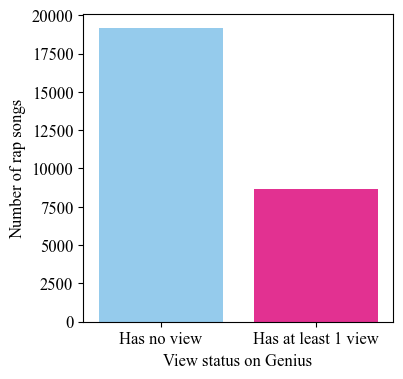

In [15]:
# Predicted variable
view = df['binary_views'].value_counts()

# Create a new index with custom labels: 'Has no view' and 'Has at least 1 view'
view.index = ['Has no view', 'Has at least 1 view']

plt.figure(figsize=(4, 4))

# Create a barplot with the custom colors for 'No' and 'Yes'
sns.barplot(x=view.index, y=view.values, palette=['lightskyblue', 'deeppink'])

# Add labels
plt.ylabel('Number of rap songs')
plt.xlabel('View status on Genius')

# Show the plot
plt.show()

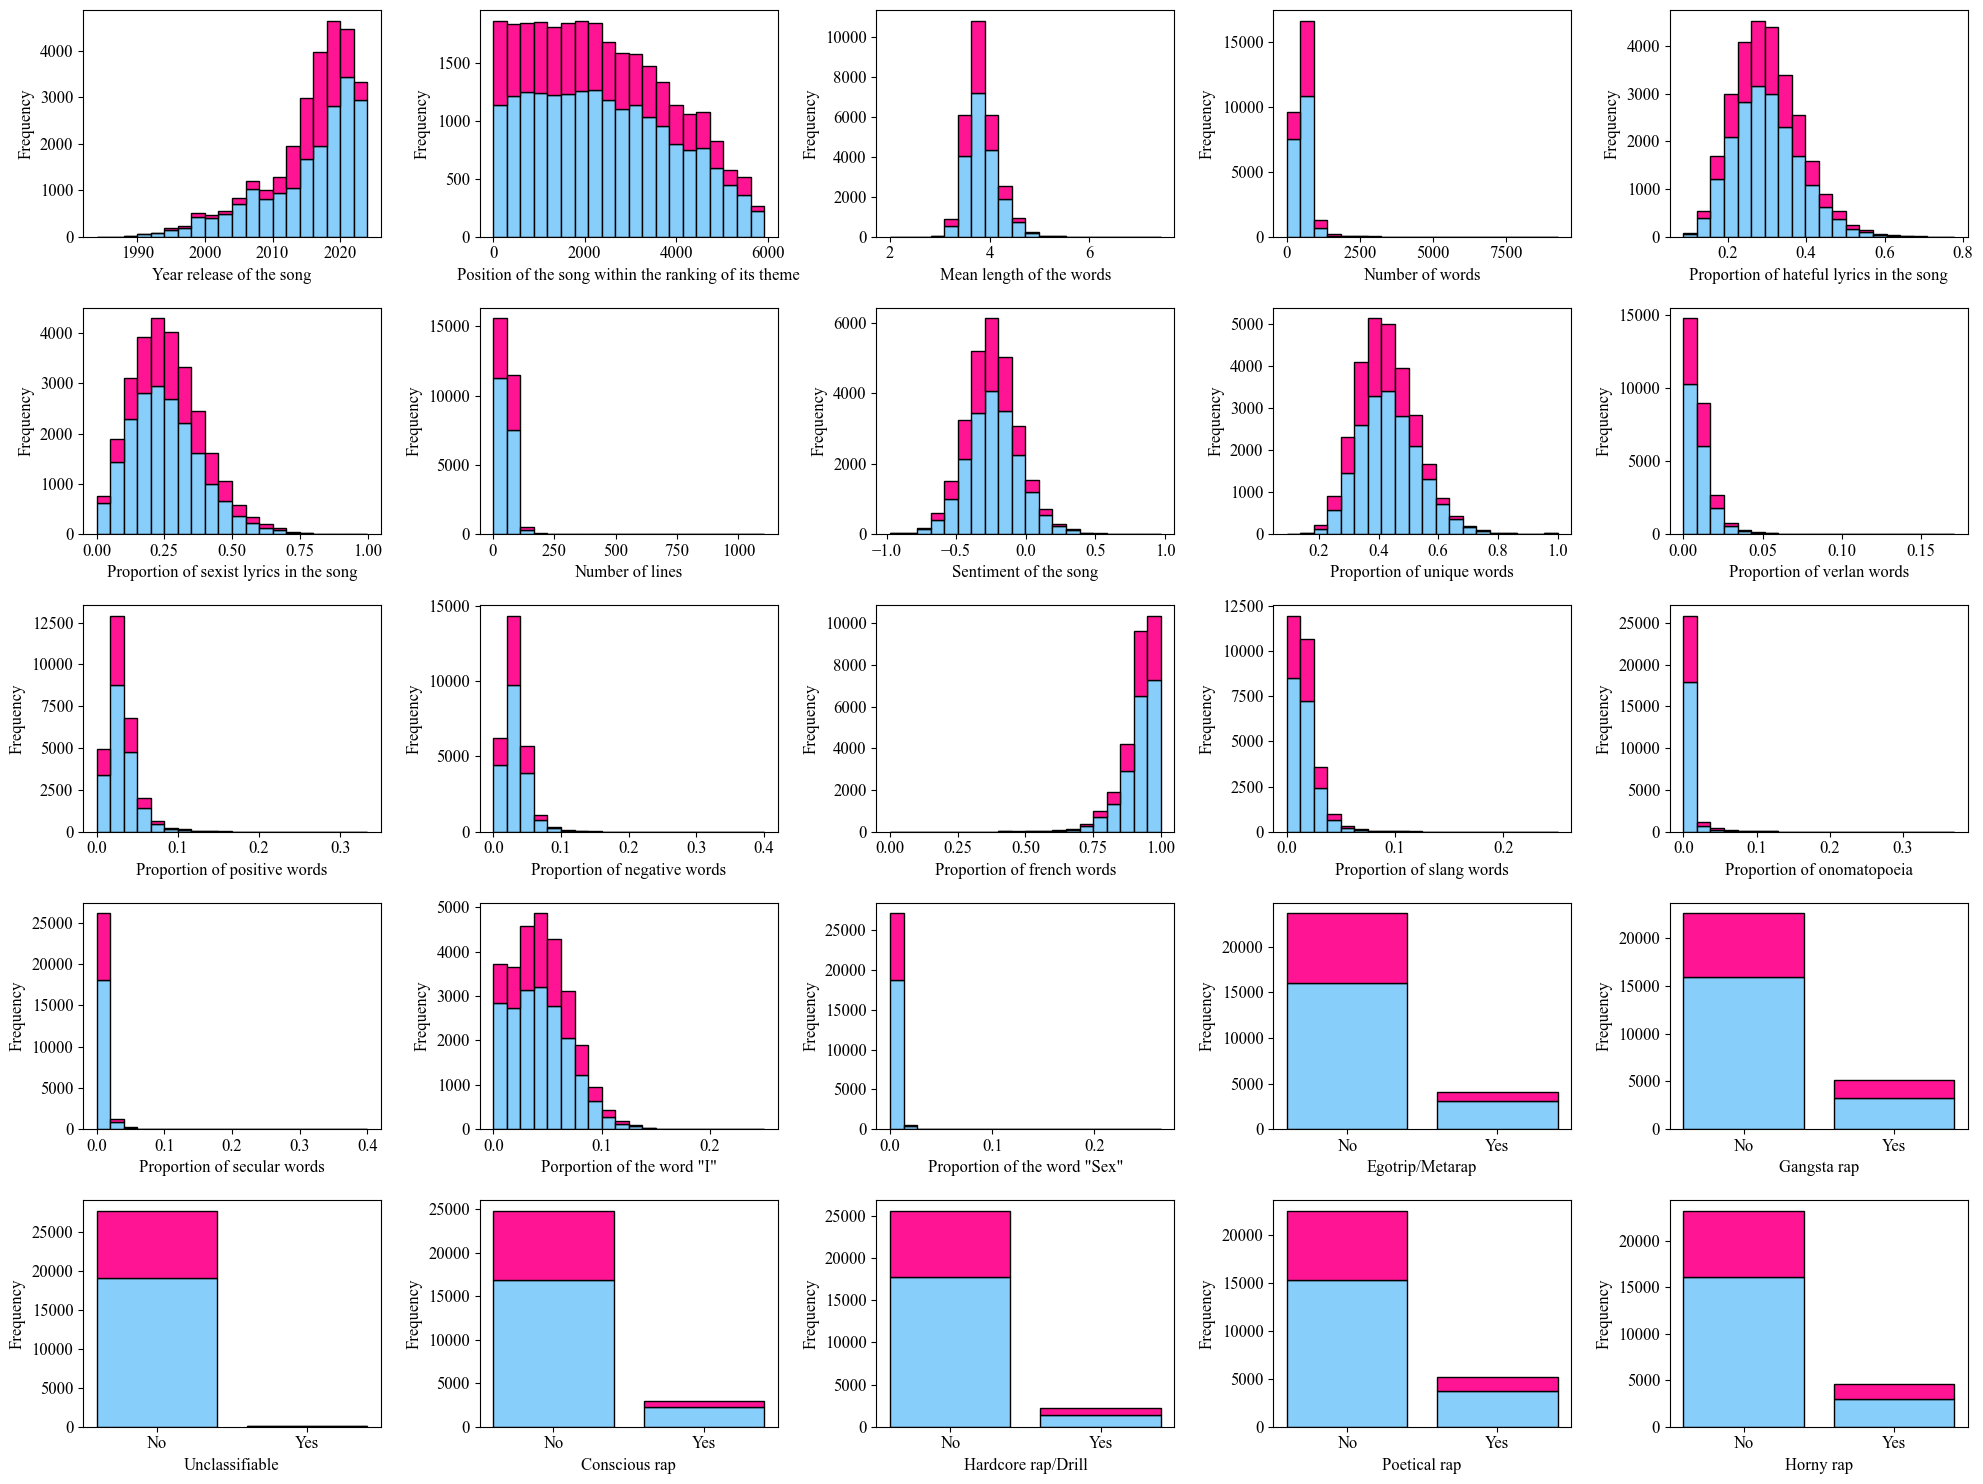

In [16]:
# Creating graphics to describe the independent variables
def plot_histograms_and_barplots(df):

    # Custom mapping for the labels
    column_labels = {
        'year': 'Year release of the song',
        'ranking': 'Position of the song within the ranking of its theme',
        'I_ratio': 'Porportion of the word "I"',
        'profanity_ratio': 'Proportion of secular words',
        'verlan_ratio': 'Proportion of verlan words',
        'french_ratio': 'Proportion of french words',
        'means_word_length': 'Mean length of the words',
        'unique_words_ratio': 'Proportion of unique words',
        'n_words': 'Number of words',
        'argot_ratio': 'Proportion of slang words',
        'onomatopoeia_ratio': 'Proportion of onomatopoeia',
        'negative_ratio': 'Proportion of negative words',
        'positive_ratio': 'Proportion of positive words',
        'sex_ratio': 'Proportion of the word "Sex"',
        'hate': 'Proportion of hateful lyrics in the song',
        'sexism': 'Proportion of sexist lyrics in the song',
        'n_lines': 'Number of lines',
        'sentiment2': 'Sentiment of the song',
    }

    # Columns to be treated as binary and have their values replaced with 'Yes'/'No'
    binary_cols = [
        'Egotrip/Metarap',
        'Gangsta rap', 'Unclassifiable',
        'Conscious rap',
        'Hardcore rap/Drill', 'Poetical rap',
        'Horny rap'
    ]
    
    # Get numerical columns excluding binary columns
    num_cols = df.select_dtypes(include=[np.number]).columns
    num_cols = [col for col in num_cols if col not in binary_cols and col != 'title_len']  # Exclude 'title_len'
    
    # Combine numerical and binary columns, with binary ones at the end
    all_cols = num_cols + binary_cols
    
    n_plots = len(all_cols)
    n_cols = 5
    n_rows = 5
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(all_cols):
        if col == 'binary_views':
            continue
        
        # Map the column name to the custom label
        label = column_labels.get(col, col)

        unique_values = df[col].nunique()

        # If the column is binary, replace values with 'Yes'/'No'
        if col in binary_cols:
            value_counts_0 = df[df['binary_views'] == 0][col].replace({0: 'No', 1: 'Yes'}).value_counts()
            value_counts_1 = df[df['binary_views'] == 1][col].replace({0: 'No', 1: 'Yes'}).value_counts()
            combined_index = value_counts_0.index.union(value_counts_1.index)
            value_counts_0 = value_counts_0.reindex(combined_index, fill_value=0)
            value_counts_1 = value_counts_1.reindex(combined_index, fill_value=0)

            axes[i - 1].bar(combined_index, value_counts_0, color='lightskyblue', label='binary_views = 0', edgecolor='k')
            axes[i - 1].bar(combined_index, value_counts_1, bottom=value_counts_0, color='deeppink', label='binary_views = 1', edgecolor='k')
            axes[i - 1].set_xlabel(label)
            axes[i - 1].set_ylabel('Frequency')

        # If fewer than 20 unique values, plot a barplot
        elif unique_values < 20:
            value_counts_0 = df[df['binary_views'] == 0][col].value_counts()
            value_counts_1 = df[df['binary_views'] == 1][col].value_counts()
            combined_index = value_counts_0.index.union(value_counts_1.index)
            value_counts_0 = value_counts_0.reindex(combined_index, fill_value=0)
            value_counts_1 = value_counts_1.reindex(combined_index, fill_value=0)
            
            axes[i].bar(combined_index, value_counts_0, color='lightskyblue', label='binary_views = 0', edgecolor='k')
            axes[i].bar(combined_index, value_counts_1, bottom=value_counts_0, color='deeppink', label='binary_views = 1', edgecolor='k')
            axes[i].set_xlabel(label)
            axes[i].set_ylabel('Frequency')
        
        # Otherwise, plot a histogram
        else:
            axes[i].hist([df[df['binary_views'] == 0][col].dropna(), df[df['binary_views'] == 1][col].dropna()], 
                         bins=20, color=['lightskyblue', 'deeppink'], edgecolor='k', label=['binary_views = 0', 'binary_views = 1'], stacked=True)
            axes[i].set_xlabel(label)
            axes[i].set_ylabel('Frequency')

    # Remove unused subplots
    for j in range(i, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_histograms_and_barplots(df)

## 5. Data standardization

In [17]:
# Separate the target variable
y = df['binary_views']
features = df.drop(columns=['binary_views'])

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(features)
X = pd.DataFrame(X, columns = features.columns)

# Merge the data
df_scaled = X.copy()
df_scaled['binary_views'] = y.reset_index(drop=True)  # Make sure the index matches

## 6. Multivariate representation

In [18]:
# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(df_scaled)

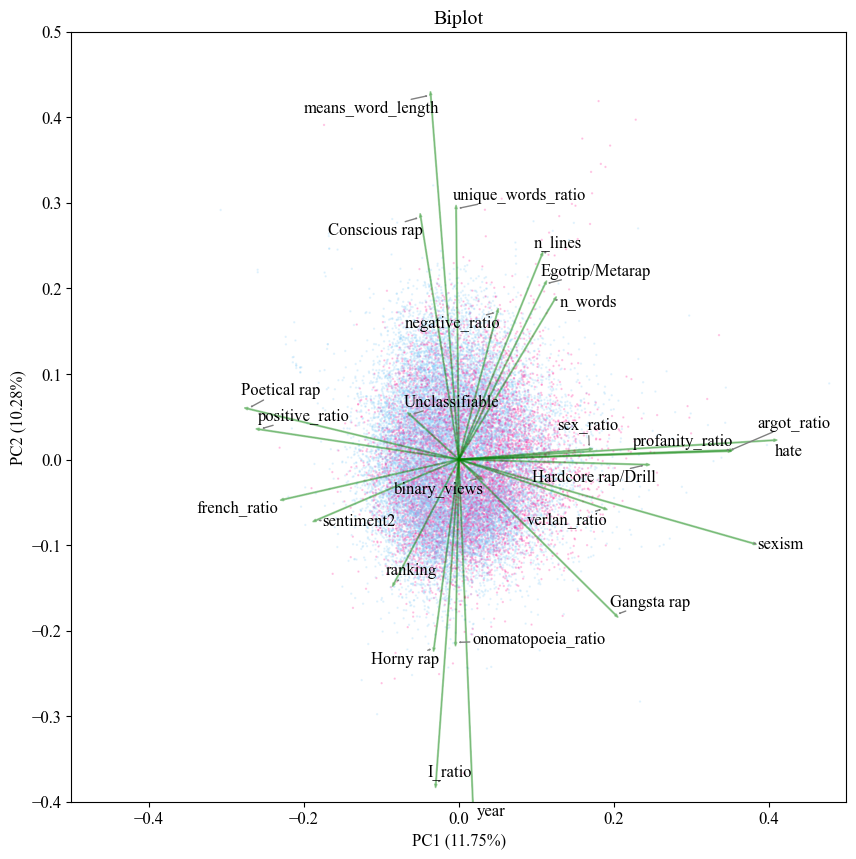

In [19]:
# Principal component analysis
def biplot(scores, coefficients, labels, binary_views, num_components=2):
    xs = scores[:, 0]
    ys = scores[:, 1]
    n = coefficients.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    # Create a color map
    colors = np.where(binary_views == 1, 'deeppink', 'lightskyblue')

    # Plot the scores with colors based on binary_views
    plt.scatter(xs * scalex, ys * scaley, c = colors, alpha = 0.2, s = 0.5)

    texts = []
    for i in range(n):
        plt.arrow(0, 0, coefficients[i, 0], coefficients[i, 1], color='green', alpha=0.35)
        text = plt.text(coefficients[i, 0], coefficients[i, 1], labels[i], color='black', ha='center', va='center')
        texts.append(text)

    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.title('Biplot')

    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.4, 0.5)

plt.figure(figsize=(10, 10))
biplot(principal_components, np.transpose(pca.components_[0:2, :]), df.columns, df['binary_views'])
plt.show()

## 6. Train / test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 666)

## 7. Data modeling : Classification 

### 7.1. Logistic Regression

In [21]:
# Performing Logistic Regression
reg = LogisticRegression()
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_[0], index=X.columns)

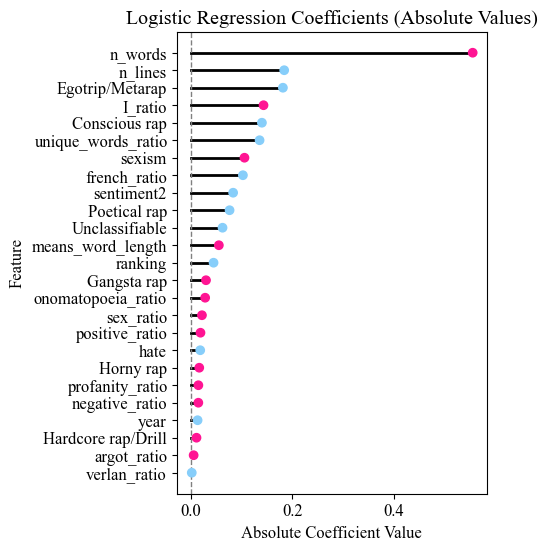

In [22]:
plot_sorted_coefficients(coef)

In [23]:
# Test the logistic regression
y_pred = reg.predict(X_test)

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['No views', 'Views'], columns=['Predicted no views', 'Predicted views'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted no views  Predicted views
No views                3668              141
Views                   1593              157


In [25]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 68.81%


### 7.2. Logistic Regression with L1 regularization (LASSO)

In [26]:
# Performing Logistic Regression with L1 regularization
reg = LogisticRegression(penalty = 'l1', solver = 'saga', C = 0.01)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_[0], index=X.columns)

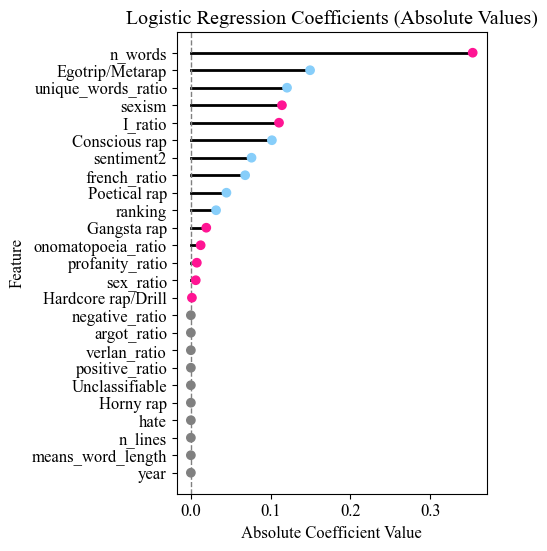

In [27]:
plot_sorted_coefficients(coef)

In [28]:
# Test the logistic regression
y_pred = reg.predict(X_test)

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['No views', 'Views'], columns = ['Predicted no views', 'Predicted views'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted no views  Predicted views
No views                3725               84
Views                   1645              105


In [30]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 68.90%


### 7.3. Logistic regression with L2 regularization (RIDGE)

In [31]:
# Performing Logistic Regression with L2 regularization
reg = LogisticRegression(penalty = 'l2', solver = 'saga', C = 0.01)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_[0], index=X.columns)

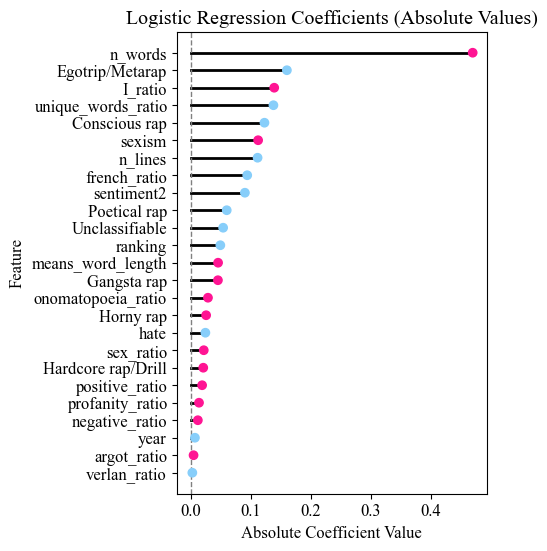

In [32]:
plot_sorted_coefficients(coef)

In [33]:
# Test the linear regression
y_pred = reg.predict(X_test)

In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index = ['Actual Win', 'Actual Loose'], columns = ['Predicted Win', 'Predicted Loose'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
              Predicted Win  Predicted Loose
Actual Win             3682              127
Actual Loose           1604              146


In [35]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 68.86%


### 7.4. Random Forest

In [36]:
# Construct the random forest
model = RandomForestClassifier(n_estimators = 1000, random_state = 666, max_depth = 8)

# Train the model
model.fit(X_train, y_train)

# Predict on the training set
y_pred_random_forest = model.predict(X_test)

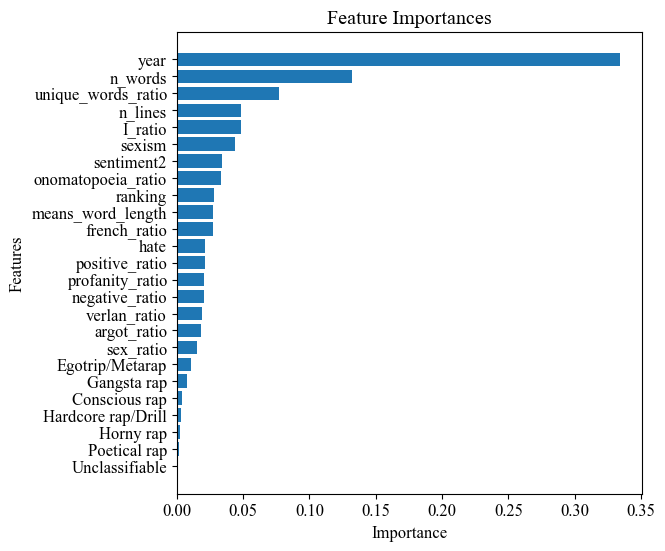

In [37]:
# Plot the feature importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(X_train.shape[1]), importances[indices], align = "center")
plt.yticks(ticks = range(X_train.shape[1]), labels = [X_train.columns[i] for i in indices])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # To have the most important feature at the top
plt.show()

In [38]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_random_forest)
cm_df = pd.DataFrame(cm, index=['No views', 'Views'], columns=['Predicted no views', 'Predicted views'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted no views  Predicted views
No views                3641              168
Views                   1439              311


In [39]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 68.86%


### 7.5. Small neural network

In [40]:
# Recreate a standardized train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 666)

In [41]:
# Simple Neural Network with one hidden layer (2 neurons)
clf_2_neurons = MLPClassifier(hidden_layer_sizes=(2,), activation='relu',
                                solver='adam', max_iter=10000, alpha=2, tol=1e-6, batch_size=1000,
                                random_state=666, verbose=True)

# Train the network
clf_2_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_2_neurons.predict(X_test)

Iteration 1, loss = 0.86064489
Iteration 2, loss = 0.83466216
Iteration 3, loss = 0.81085125
Iteration 4, loss = 0.78984282
Iteration 5, loss = 0.77123058
Iteration 6, loss = 0.75489296
Iteration 7, loss = 0.74083633
Iteration 8, loss = 0.72858727
Iteration 9, loss = 0.71788139
Iteration 10, loss = 0.70839132
Iteration 11, loss = 0.69976098
Iteration 12, loss = 0.69198797
Iteration 13, loss = 0.68489765
Iteration 14, loss = 0.67832520
Iteration 15, loss = 0.67203147
Iteration 16, loss = 0.66611934
Iteration 17, loss = 0.66050252
Iteration 18, loss = 0.65517821
Iteration 19, loss = 0.65001730
Iteration 20, loss = 0.64490829
Iteration 21, loss = 0.64008213
Iteration 22, loss = 0.63537437
Iteration 23, loss = 0.63091665
Iteration 24, loss = 0.62669247
Iteration 25, loss = 0.62260046
Iteration 26, loss = 0.61873315
Iteration 27, loss = 0.61507561
Iteration 28, loss = 0.61149572
Iteration 29, loss = 0.60815512
Iteration 30, loss = 0.60501171
Iteration 31, loss = 0.60195395
Iteration 32, los

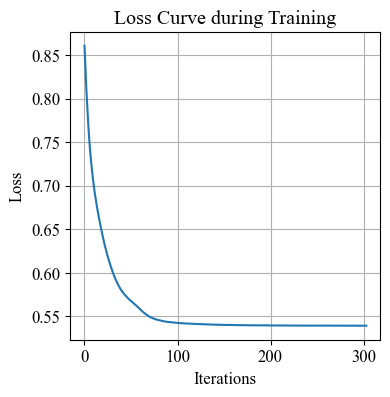

In [42]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_2_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [43]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Confusion matrix
cm_df = pd.DataFrame(cm, index=['No views', 'Views'], columns=['Predicted no views', 'Predicted views'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted no views  Predicted views
No views                3411              398
Views                   1171              579


In [44]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 71.78%


### 7.6. Large neural network

In [45]:
# Large Neural Network with three hidden layers ([100, 50] neurons)
clf_150_neurons = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                                solver='adam', max_iter=1000, alpha=0.001, tol=1e-6, batch_size=100,
                                learning_rate='adaptive', random_state=666, verbose=True)

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

Iteration 1, loss = 0.59043439
Iteration 2, loss = 0.55222871
Iteration 3, loss = 0.53267721
Iteration 4, loss = 0.52302281
Iteration 5, loss = 0.51792498
Iteration 6, loss = 0.51291470
Iteration 7, loss = 0.50972112
Iteration 8, loss = 0.50596473
Iteration 9, loss = 0.50351702
Iteration 10, loss = 0.50059893
Iteration 11, loss = 0.49814064
Iteration 12, loss = 0.49501136
Iteration 13, loss = 0.49267147
Iteration 14, loss = 0.48953789
Iteration 15, loss = 0.48775789
Iteration 16, loss = 0.48440330
Iteration 17, loss = 0.48273618
Iteration 18, loss = 0.48015594
Iteration 19, loss = 0.47787979
Iteration 20, loss = 0.47557393
Iteration 21, loss = 0.47298141
Iteration 22, loss = 0.47086673
Iteration 23, loss = 0.46855030
Iteration 24, loss = 0.46675548
Iteration 25, loss = 0.46347909
Iteration 26, loss = 0.46100911
Iteration 27, loss = 0.45788655
Iteration 28, loss = 0.45713898
Iteration 29, loss = 0.45384814
Iteration 30, loss = 0.45112343
Iteration 31, loss = 0.45011190
Iteration 32, los

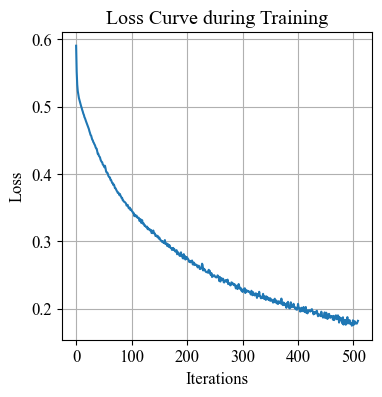

In [46]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [47]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Confusion matrix
cm_df = pd.DataFrame(cm, index=['No views', 'Views'], columns=['Predicted no views', 'Predicted views'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted no views  Predicted views
No views                2869              940
Views                    971              779


In [48]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 65.62%


### 7.7. Large neural network with heavy peanalization

In [49]:
# Large Neural Network with three hidden layers ([100, 50] neurons)
clf_150_neurons_penalty = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                                solver='adam', max_iter=1000, alpha=7.5, tol=1e-6, batch_size=1000,
                                random_state=666, verbose=True)

# Train the network
clf_150_neurons_penalty.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons_penalty.predict(X_test)

Iteration 1, loss = 1.05664338
Iteration 2, loss = 0.93510691
Iteration 3, loss = 0.86660641
Iteration 4, loss = 0.81135246
Iteration 5, loss = 0.76624025
Iteration 6, loss = 0.72880407
Iteration 7, loss = 0.69834291
Iteration 8, loss = 0.67257559
Iteration 9, loss = 0.65120784
Iteration 10, loss = 0.63327900
Iteration 11, loss = 0.61880915
Iteration 12, loss = 0.60711346
Iteration 13, loss = 0.59782669
Iteration 14, loss = 0.59077599
Iteration 15, loss = 0.58498267
Iteration 16, loss = 0.58073392
Iteration 17, loss = 0.57735003
Iteration 18, loss = 0.57445528
Iteration 19, loss = 0.57164106
Iteration 20, loss = 0.57002522
Iteration 21, loss = 0.56848671
Iteration 22, loss = 0.56713120
Iteration 23, loss = 0.56612119
Iteration 24, loss = 0.56497886
Iteration 25, loss = 0.56425369
Iteration 26, loss = 0.56284445
Iteration 27, loss = 0.56220931
Iteration 28, loss = 0.56190857
Iteration 29, loss = 0.56135874
Iteration 30, loss = 0.56131753
Iteration 31, loss = 0.56066670
Iteration 32, los

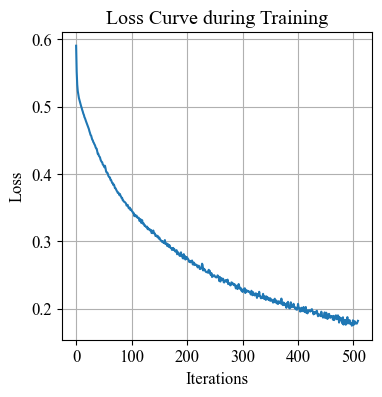

In [50]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [51]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Confusion matrix
cm_df = pd.DataFrame(cm, index=['No views', 'Views'], columns=['Predicted no views', 'Predicted views'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          Predicted no views  Predicted views
No views                3441              368
Views                   1178              572


In [52]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

Accuracy of the model: 72.19%


## 8. Conclusion

The best model is a neural network with a 100-neuron layer and a 50-neuron layer and a heavy penalization. The accuracy is 72.19%, which is too low predict whether a rap song's lyrics or their meaning are going to be watched at least once on the website Genius.

# Bonus: predict the number of views a page has

Now that we have tried to predict whether a page will be viewed or not, let us try to predict the number of views a page has when it is viewed at least once.

**Objective** : Predict the number of views (at the logarithmic scale) a page has, among the ones that viewed at least once.

## 1. Data manipulation

For this part, I will use the copy of the DataFrame made earlier

In [53]:
# Dropping empty values of the copy of the DataFrame
df_copy = df_copy.dropna()
df_copy = df_copy[~df.isin(['NaN']).any(axis=1)]

# Drop rows where 'binary_views' is 0
df_copy = df_copy[df_copy['binary_views'] != 0]

# Drop the 'binary_views' column afterwards
df_copy = df_copy.drop(columns=['binary_views'], axis=1)

## 2. Data standardization

In [54]:
cols = [col for col in df_copy.drop('log_pageviews', axis = 1).columns]

scaler = StandardScaler()
df_copy[cols] = pd.DataFrame(scaler.fit_transform(df_copy[cols]), index = df_copy.index)

In [55]:
df_copy

,year,ranking,means_word_length,n_words,hate,sexism,n_lines,sentiment2,Egotrip/Metarap,Gangsta rap,Unclassifiable,Conscious rap,Horny rap,Hardcore rap/Drill,Poetical rap,unique_words_ratio,verlan_ratio,positive_ratio,negative_ratio,french_ratio,argot_ratio,onomatopoeia_ratio,profanity_ratio,I_ratio,sex_ratio,log_pageviews
7,-5.181291,-1.368581,2.049159,-0.270020,-1.391012,-1.877392,-0.058780,1.046320,-0.363497,-0.540217,-0.01075,3.282400,-0.467288,-0.322221,-0.447896,1.146962,-0.508046,0.975533,0.137810,1.042748,-0.878556,-0.228196,-0.545719,-1.178087,-0.532359,9.605688
24,-4.978222,0.215090,0.804762,-0.461209,-0.178759,1.730360,-0.231409,-0.281419,-0.363497,-0.540217,-0.01075,-0.304655,-0.467288,-0.322221,-0.447896,0.564658,2.066218,0.875877,-0.943067,0.974049,1.662975,-0.350673,-0.518784,-0.116439,-0.116564,11.517166
26,-4.978222,-0.604003,0.189749,-0.591565,-0.792479,-1.665348,-0.404038,1.981043,2.751057,-0.540217,-0.01075,-0.304655,-0.467288,-0.322221,-0.447896,0.818092,-0.855111,-0.285782,-0.839713,0.577389,-0.259243,-0.350673,-0.740795,-1.103214,-0.532359,9.485317
27,-4.978222,-0.989657,2.573427,-0.116489,-0.365166,-1.270969,0.228935,-0.046426,-0.363497,-0.540217,-0.01075,3.282400,-0.467288,-0.322221,-0.447896,1.128095,-0.742433,-0.207111,1.048429,0.960627,-0.790548,-0.239069,-0.740795,-1.624586,-0.199444,8.699681
83,-4.775154,1.297344,0.879507,0.399143,0.581984,1.526798,0.775594,-0.159737,2.751057,-0.540217,-0.01075,-0.304655,-0.467288,-0.322221,-0.447896,1.034725,-0.127163,-0.263119,-0.020750,0.390979,1.202648,-0.178732,0.080787,-1.419246,-0.019455,9.040975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31892,1.519961,-0.634963,-0.881492,0.109462,0.505327,1.776519,-0.432809,-0.746462,-0.363497,1.851107,-0.01075,-0.304655,-0.467288,-0.322221,-0.447896,-0.572292,-0.142687,-0.715406,-0.176935,0.209434,-0.298106,-0.350673,0.045287,0.535060,-0.532359,8.532673
31893,1.519961,-0.052108,-0.409570,-0.539423,-0.852313,-0.693919,-0.720524,0.610117,-0.363497,1.851107,-0.01075,-0.304655,-0.467288,-0.322221,-0.447896,0.902933,0.095269,-0.592718,-1.278793,-0.263826,-0.958743,-0.350673,-0.740795,1.102818,-0.532359,8.529912
33516,1.723030,0.333546,-1.444040,0.103668,0.603470,2.661865,-0.231409,0.710093,-0.363497,-0.540217,-0.01075,-0.304655,2.140006,-0.322221,-0.447896,-1.746964,0.342851,0.208333,-0.348289,-0.936727,0.146081,1.728334,-0.110061,-0.494667,1.534880,8.913819
33518,1.723030,-1.359158,0.568886,0.034145,-0.356313,-0.681698,-0.547895,-0.254949,-0.363497,-0.540217,-0.01075,-0.304655,-0.467288,3.103458,-0.447896,0.189374,2.565349,-0.762086,-0.930425,-0.777658,-0.716012,1.599893,0.403807,0.211303,0.080122,8.646290


## 3. Multivariate representation

In [56]:
# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(df_copy)

In [57]:
# Principal component analysis
def biplot(scores, coefficients, labels, num_components=2):
    xs = scores[:, 0]
    ys = scores[:, 1]
    n = coefficients.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    # Plot the scores
    plt.scatter(xs * scalex, ys * scaley, c = 'deeppink', alpha = 0.2, s = 0.5)

    texts = []
    for i in range(n):
        plt.arrow(0, 0, coefficients[i, 0], coefficients[i, 1], color='green', alpha=0.35)
        text = plt.text(coefficients[i, 0], coefficients[i, 1], labels[i], color='black', ha='center', va='center')
        texts.append(text)

    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.title('Biplot')

    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.4, 0.5)

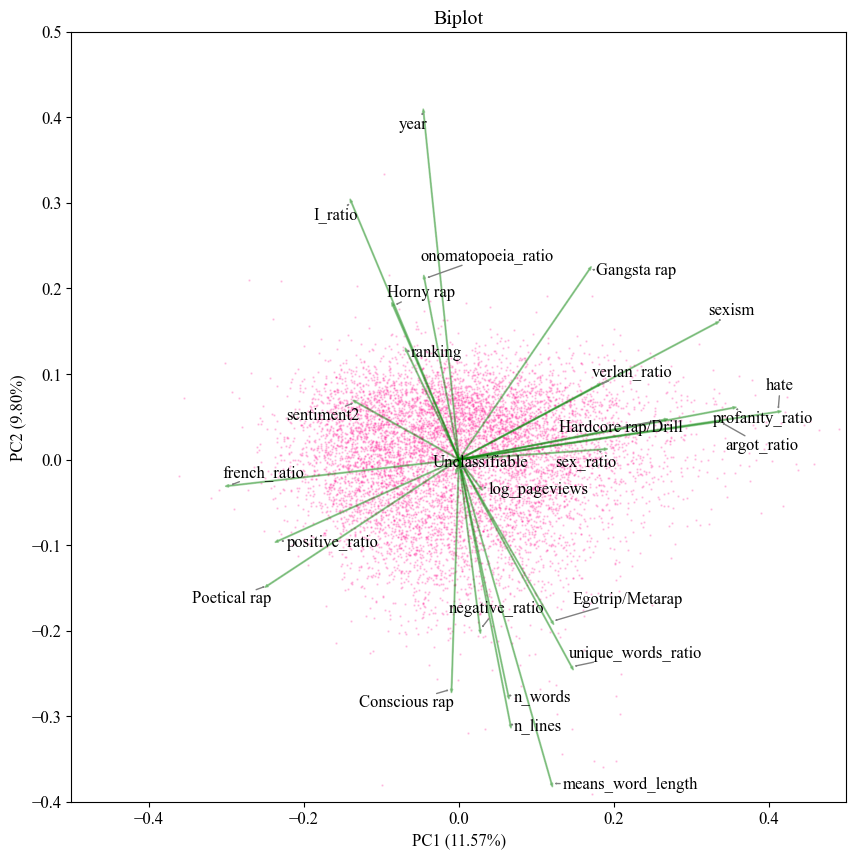

In [58]:
plt.figure(figsize=(10, 10))
biplot(principal_components, np.transpose(pca.components_[0:2, :]), df_copy.columns, df_copy['log_pageviews'])
plt.show()

## 4. Train / test split

In [59]:
# Splitting the dataset into train and test
X = df_copy.drop("log_pageviews", axis = 1)
y = df_copy["log_pageviews"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 666)

## 5. Data modeling : Regression

### 5.1. Linear regression

In [60]:
# Performing Linear Regression
reg = LinearRegression()
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_, index = X.columns)

In [61]:
# Test the regression
y_pred = reg.predict(X_test)

In [62]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.0277378095913101)

In [63]:
mean_absolute_error(y_test, y_pred)

np.float64(0.8216174076908074)

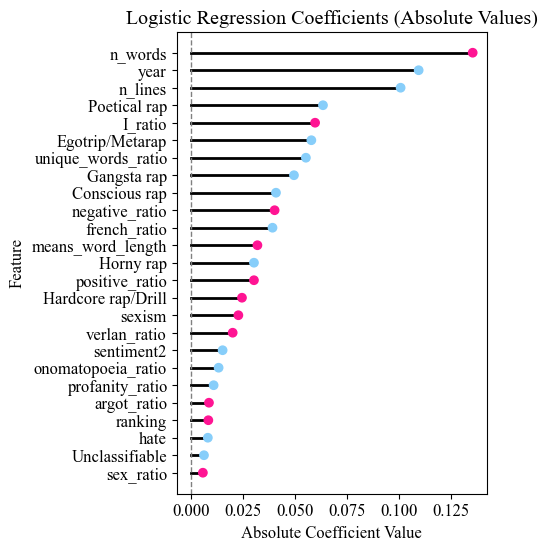

In [64]:
plot_sorted_coefficients(coef)

Text(0, 0.5, 'Predicted number of views (log scale)')

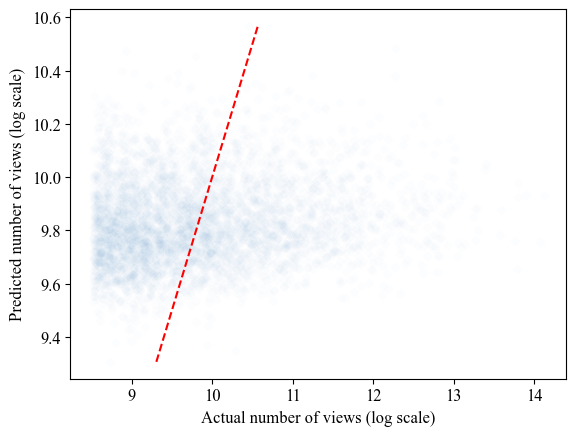

In [65]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.01)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual number of views (log scale)")
plt.ylabel("Predicted number of views (log scale)")

### 5.2. LASSO regression

In [66]:
# Performing LASSO Regression
reg = Lasso(alpha = 0.01)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_, index = X.columns)

In [67]:
# Test the regression
y_pred = reg.predict(X_test)

In [68]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.0285899810920098)

In [69]:
mean_absolute_error(y_test, y_pred)

np.float64(0.8223850015663811)

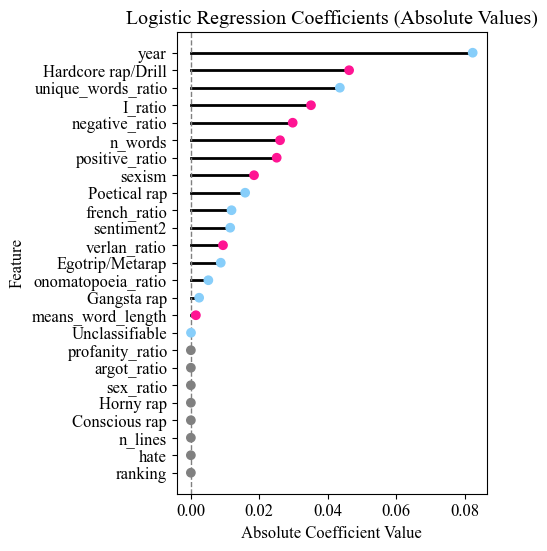

In [70]:
plot_sorted_coefficients(coef)

Text(0, 0.5, 'Predicted number of views (log scale)')

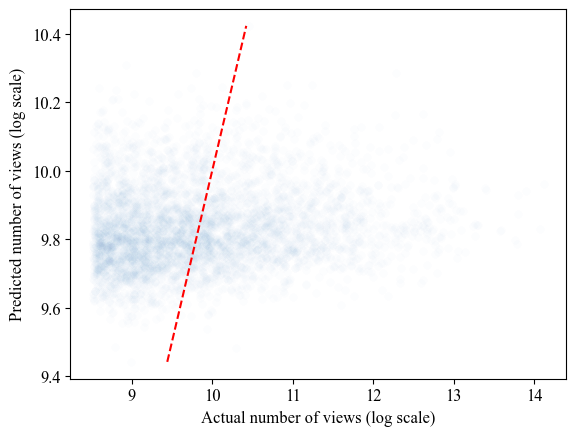

In [71]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.01)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual number of views (log scale)")
plt.ylabel("Predicted number of views (log scale)")

### 5.3. Ridge regression

In [72]:
# Performing LASSO Regression
reg = Ridge(alpha = 0.5)
reg.fit(X_train, y_train)

coef = pd.Series(reg.coef_, index = X.columns)

In [73]:
# Test the regression
y_pred = reg.predict(X_test)

In [74]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.0277371887863669)

In [75]:
mean_absolute_error(y_test, y_pred)

np.float64(0.8216178144019014)

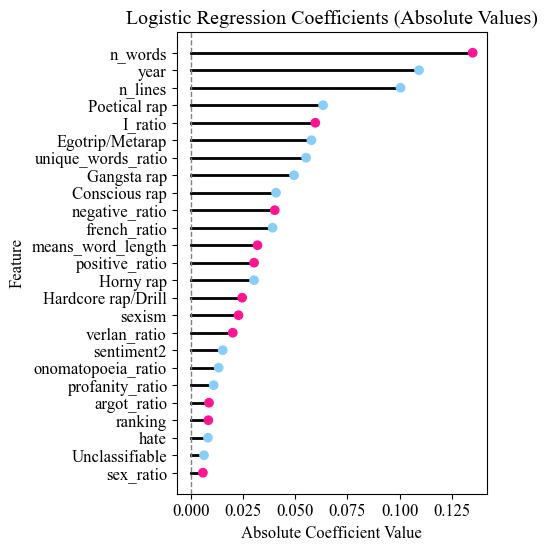

In [76]:
plot_sorted_coefficients(coef)

Text(0, 0.5, 'Predicted number of views (log scale)')

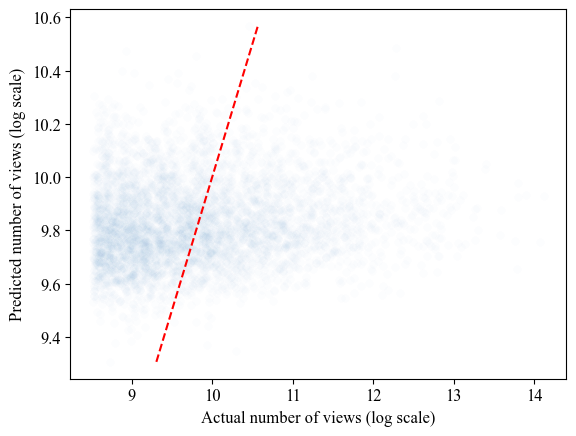

In [77]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.01)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual number of views (log scale)")
plt.ylabel("Predicted number of views (log scale)")

### 5.4. Simple Neural Network

In [78]:
# Simple Neural Network with one hidden layer (2 neurons)
clf_2_neurons = MLPRegressor(hidden_layer_sizes=(2,), activation = 'relu',
                              solver = 'adam', max_iter = 1000, alpha = 20, tol = 1e-6, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_2_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_2_neurons.predict(X_test)

Iteration 1, loss = 43.33368100
Iteration 2, loss = 43.10938613
Iteration 3, loss = 42.88767591
Iteration 4, loss = 42.67582348
Iteration 5, loss = 42.46757385
Iteration 6, loss = 42.26422435
Iteration 7, loss = 42.06566136
Iteration 8, loss = 41.87194436
Iteration 9, loss = 41.68457615
Iteration 10, loss = 41.50270770
Iteration 11, loss = 41.32672795
Iteration 12, loss = 41.15452513
Iteration 13, loss = 40.98734331
Iteration 14, loss = 40.82449610
Iteration 15, loss = 40.66643449
Iteration 16, loss = 40.51219490
Iteration 17, loss = 40.36110022
Iteration 18, loss = 40.21514922
Iteration 19, loss = 40.07087796
Iteration 20, loss = 39.93176419
Iteration 21, loss = 39.79692303
Iteration 22, loss = 39.66496481
Iteration 23, loss = 39.53635361
Iteration 24, loss = 39.41034890
Iteration 25, loss = 39.28845504
Iteration 26, loss = 39.16859854
Iteration 27, loss = 39.05216463
Iteration 28, loss = 38.93802652
Iteration 29, loss = 38.82707683
Iteration 30, loss = 38.71828608
Iteration 31, loss 

c:\Users\bouzi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [79]:
# Test the regression
y_pred = reg.predict(X_test)

In [80]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.0277371887863669)

In [81]:
mean_absolute_error(y_test, y_pred)

np.float64(0.8216178144019014)

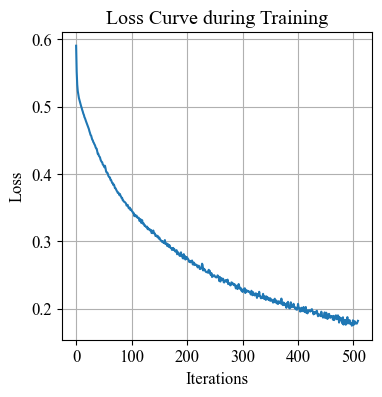

In [82]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Predicted number of views (log scale)')

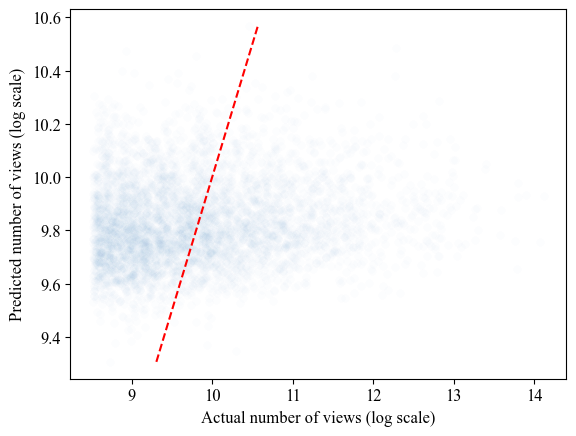

In [83]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.01)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual number of views (log scale)")
plt.ylabel("Predicted number of views (log scale)")

### 5.5. Large Neural Network

In [84]:
# Large Neural Network with three hidden layers ([100,50] neurons)
clf_150_neurons = MLPRegressor(hidden_layer_sizes = (100,50), activation = 'relu',
                              solver = 'adam', max_iter = 1000, alpha = 1, tol = 1e-6, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons.predict(X_test)

Iteration 1, loss = 42.72768252
Iteration 2, loss = 36.40564088
Iteration 3, loss = 30.27182918
Iteration 4, loss = 24.44566850
Iteration 5, loss = 18.89097873
Iteration 6, loss = 14.22032062
Iteration 7, loss = 10.39276509
Iteration 8, loss = 7.79087291
Iteration 9, loss = 6.38897508
Iteration 10, loss = 5.69032642
Iteration 11, loss = 5.18358871
Iteration 12, loss = 4.70792063
Iteration 13, loss = 4.20979026
Iteration 14, loss = 3.73713572
Iteration 15, loss = 3.39338259
Iteration 16, loss = 3.23105900
Iteration 17, loss = 2.95987814
Iteration 18, loss = 2.80341168
Iteration 19, loss = 2.61122513
Iteration 20, loss = 2.44157703
Iteration 21, loss = 2.33052337
Iteration 22, loss = 2.23014133
Iteration 23, loss = 2.13364610
Iteration 24, loss = 2.05193014
Iteration 25, loss = 1.97296803
Iteration 26, loss = 1.90384357
Iteration 27, loss = 1.84470644
Iteration 28, loss = 1.78625982
Iteration 29, loss = 1.72875791
Iteration 30, loss = 1.67696872
Iteration 31, loss = 1.63068008
Iteration 

In [85]:
# Test the regression
y_pred = reg.predict(X_test)

In [86]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.0277371887863669)

In [87]:
mean_absolute_error(y_test, y_pred)

np.float64(0.8216178144019014)

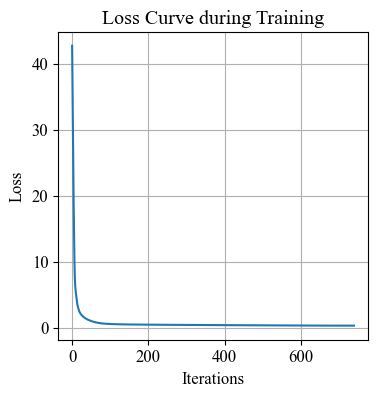

In [88]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Predicted number of views (log scale)')

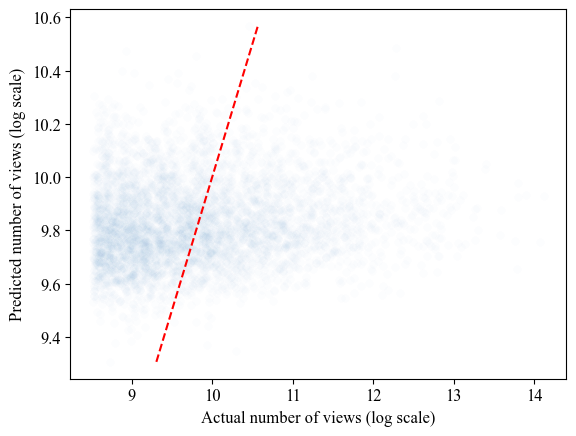

In [89]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.01)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual number of views (log scale)")
plt.ylabel("Predicted number of views (log scale)")

### 5.6. Large Neural Network with higher tolerance and heavy penalization

In [90]:
# Large Neural Network with two hidden layers ([100,50] neurons)
clf_150_neurons_2 = MLPRegressor(hidden_layer_sizes = (100,50), activation = 'relu',
                              solver = 'adam', max_iter = 1000, alpha = 20, tol = 1e-3, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_150_neurons_2.fit(X_train, y_train)

# Predict on the test set
y_pred = clf_150_neurons_2.predict(X_test)

Iteration 1, loss = 43.93645234
Iteration 2, loss = 37.62509033
Iteration 3, loss = 31.50909554
Iteration 4, loss = 25.70223168
Iteration 5, loss = 20.17024567
Iteration 6, loss = 15.50498791
Iteration 7, loss = 11.67805105
Iteration 8, loss = 9.06655441
Iteration 9, loss = 7.65119426
Iteration 10, loss = 6.94665727
Iteration 11, loss = 6.44333845
Iteration 12, loss = 5.97247848
Iteration 13, loss = 5.47943192
Iteration 14, loss = 5.01166386
Iteration 15, loss = 4.66920390
Iteration 16, loss = 4.50232519
Iteration 17, loss = 4.23024409
Iteration 18, loss = 4.06814079
Iteration 19, loss = 3.87113658
Iteration 20, loss = 3.69517154
Iteration 21, loss = 3.57651673
Iteration 22, loss = 3.46692797
Iteration 23, loss = 3.36035251
Iteration 24, loss = 3.27008030
Iteration 25, loss = 3.18188800
Iteration 26, loss = 3.10389966
Iteration 27, loss = 3.03535961
Iteration 28, loss = 2.96683664
Iteration 29, loss = 2.89839607
Iteration 30, loss = 2.83566681
Iteration 31, loss = 2.77818351
Iteration 

In [91]:
# Test the regression
y_pred = reg.predict(X_test)

In [92]:
# Compute the rooted mean square error
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.0277371887863669)

In [93]:
mean_absolute_error(y_test, y_pred)

np.float64(0.8216178144019014)

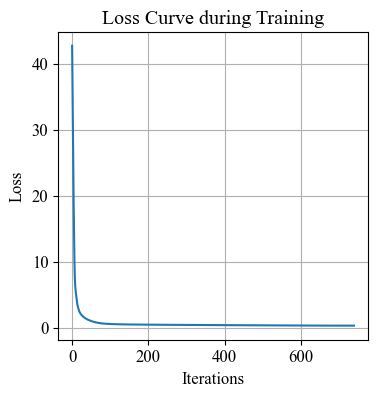

In [94]:
# Plot the loss curve
plt.figure(figsize = (4, 4))
plt.plot(clf_150_neurons.loss_curve_)
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Predicted number of views (log scale)')

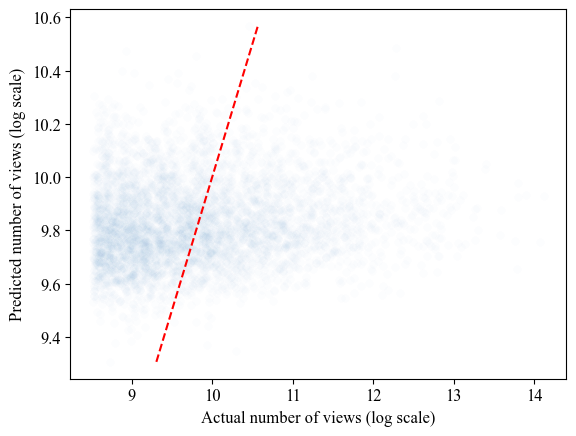

In [95]:
sns.scatterplot(x = y_test, y = y_pred,  alpha = 0.01)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], linestyle='--', color='red')
plt.xlabel("Actual number of views (log scale)")
plt.ylabel("Predicted number of views (log scale)")

## 6. Conclusion

The mean absolute error is equal to 0.8216, and is minimized by linear regression, ridge regression or neural network (equivalent performance). It therefore seems not possible to predict the number of views a Genius rap page will get, as 0.8216 is a quite important number in log scale.